# 08 Multiple Linear Regression

## Full OLS Model Using Encoded Predictors

This notebook:
- Loads encoded train/test datasets
- Fits a full multiple linear regression with statsmodels OLS
- Evaluates on the test set
- Prints metrics and a coefficient significance table

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [8]:
train_path = Path('../data/processed/ElectraHub_train_encoded.csv')
test_path = Path('../data/processed/ElectraHub_test_encoded.csv')

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError('Encoded train/test files are missing in ../data/processed/')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f'Loaded train: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'Loaded test : {test_df.shape[0]:,} rows x {test_df.shape[1]} columns')

Loaded train: 2,400 rows x 20 columns
Loaded test : 600 rows x 20 columns


In [9]:
TARGET_COL = 'Sales'

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

ols_full = sm.OLS(y_train, X_train_const).fit()

In [10]:
y_test_pred = ols_full.predict(X_test_const)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred) ** 0.5
mae_test = mean_absolute_error(y_test, y_test_pred)

# Adjusted R^2 on test set using test-sample formula
n_test = len(y_test)
p = X_test.shape[1]
adj_r2_test = 1 - (1 - r2_test) * ((n_test - 1) / (n_test - p - 1))

f_stat = ols_full.fvalue

print('Test-Set Performance Metrics')
print(f'R^2 (test): {r2_test:.6f}')
print(f'Adjusted R^2 (test): {adj_r2_test:.6f}')
print(f'RMSE (test): {rmse_test:,.4f}')
print(f'MAE (test): {mae_test:,.4f}')
print(f'F-statistic (train model): {f_stat:,.4f}')

Test-Set Performance Metrics
R^2 (test): 0.915997
Adjusted R^2 (test): 0.913245
RMSE (test): 2,042.2397
MAE (test): 1,644.3311
F-statistic (train model): 1,251.2944


In [11]:
coef_table = pd.DataFrame({
    'feature': ols_full.params.index,
    'coefficient': ols_full.params.values,
    'p_value': ols_full.pvalues.values
})
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
coef_table = coef_table.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

print('Coefficients and p-values (sorted by absolute coefficient)')
display(coef_table[['feature', 'coefficient', 'p_value']])

Coefficients and p-values (sorted by absolute coefficient)


,feature,coefficient,p_value
0,const,-44520.800562,2.180588e-134
1,Competitor_Price_Index,-10823.747252,1.028914e-79
2,Avg_Customer_Rating,10566.770611,1.513778e-151
3,Return_Rate,-1578.931151,1.001964e-42
4,Popularity,1523.763402,6.541668e-138
5,Region_North,-1054.650537,1.317085e-16
6,Campaign_Type_Influencer,916.958986,1.111099e-09
7,Region_South,-762.582773,9.610168e-10
8,Campaign_Type_Social Media,620.316836,1.969023e-06
9,Product_Category_Tablet,433.073379,1.885012e-05


In [12]:
print('Full OLS Summary')
print(ols_full.summary())

Full OLS Summary
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     1251.
Date:                Fri, 24 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:01:54   Log-Likelihood:                -21801.
No. Observations:                2400   AIC:                         4.364e+04
Df Residuals:                    2380   BIC:                         4.376e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
con

## Assumption Checks and Multicollinearity (VIF)

Diagnostics added for the full multiple linear regression model:
- Residuals vs Fitted plot
- Q-Q plot of residuals
- Durbin-Watson statistic
- Jarque-Bera normality test
- Breusch-Pagan heteroscedasticity test
- VIF table for all predictors


In [13]:
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

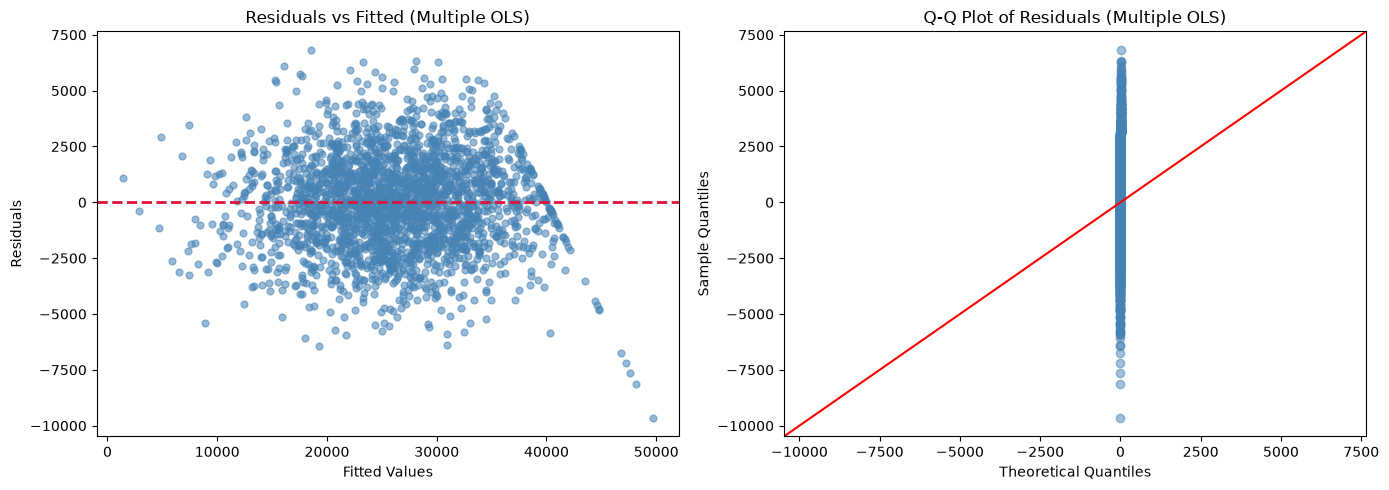

In [14]:
# Residual diagnostics on training fit
train_fitted = ols_full.predict(X_train_const)
train_residuals = y_train - train_fitted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(train_fitted, train_residuals, alpha=0.55, s=24, color='steelblue')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Fitted (Multiple OLS)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q Plot
qqplot(train_residuals, line='45', ax=axes[1], markerfacecolor='steelblue', markeredgecolor='steelblue', alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals (Multiple OLS)')

plt.tight_layout()
plt.show()

In [15]:
# Assumption test statistics

dw_stat = durbin_watson(train_residuals)
jb_stat, jb_p = jarque_bera(train_residuals)
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(train_residuals, X_train_const)

print('Durbin-Watson:', round(dw_stat, 4))
print('Jarque-Bera statistic:', round(jb_stat, 4), '| p-value:', f'{jb_p:.6g}')
print('Breusch-Pagan LM statistic:', round(bp_lm, 4), '| p-value:', f'{bp_lm_p:.6g}')
print('Breusch-Pagan F statistic :', round(bp_f, 4), '| p-value:', f'{bp_f_p:.6g}')

Durbin-Watson: 1.9951
Jarque-Bera statistic: 6.9053 | p-value: 0.0316622
Breusch-Pagan LM statistic: 22.3626 | p-value: 0.266582
Breusch-Pagan F statistic : 1.1782 | p-value: 0.266722


In [16]:
# VIF table for all predictors (exclude intercept)
X_vif = X_train.copy()

vif_df = pd.DataFrame({
    'predictor': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF Table (sorted descending)')
display(vif_df)

VIF Table (sorted descending)


,predictor,VIF
0,Avg_Customer_Rating,244.443031
1,Competitor_Price_Index,145.833048
2,Advertising_Expenditure,62.772384
3,Return_Rate,45.101921
4,Discount_Percentage,37.592733
5,Campaign_Engagement_Score,24.713591
6,Length_Product_Description,16.447392
7,Popularity,14.089417
8,Inventory_Level,9.372950
9,Product_Price,4.623199


## Final Model Comparison on Test Set

Side-by-side comparison of:
- Naive baseline
- Three simple linear regression models
- Full multiple linear regression model

In [17]:
raw_train_path = Path('../data/processed/splits/ElectraHub_train.csv')
raw_test_path = Path('../data/processed/splits/ElectraHub_test.csv')

raw_train_df = pd.read_csv(raw_train_path)
raw_test_df = pd.read_csv(raw_test_path)

y_test_all = raw_test_df['Sales']
n_test = len(y_test_all)

comparison_rows = []

def adjusted_r2(r2_value, n_obs, n_predictors):
    if n_obs <= n_predictors + 1:
        return np.nan
    return 1 - (1 - r2_value) * ((n_obs - 1) / (n_obs - n_predictors - 1))

# 1) Naive baseline: predict train mean
naive_pred = np.full(shape=n_test, fill_value=raw_train_df['Sales'].mean())
naive_r2 = r2_score(y_test_all, naive_pred)
comparison_rows.append({
    'Model': 'Naive baseline (train mean)',
    'Predictor(s)': 'None',
    'R² (test)': naive_r2,
    'Adjusted R² (test)': adjusted_r2(naive_r2, n_test, 0),
    'RMSE (test)': mean_squared_error(y_test_all, naive_pred) ** 0.5,
    'MAE (test)': mean_absolute_error(y_test_all, naive_pred)
})

# 2) Three simple models on raw split
simple_predictors = [
    'Campaign_Engagement_Score',
    'Advertising_Expenditure',
    'Avg_Customer_Rating'
]

for predictor in simple_predictors:
    X_train_one = sm.add_constant(raw_train_df[[predictor]], has_constant='add')
    X_test_one = sm.add_constant(raw_test_df[[predictor]], has_constant='add')

    simple_model = sm.OLS(raw_train_df['Sales'], X_train_one).fit()
    y_test_pred_one = simple_model.predict(X_test_one)

    r2_one = r2_score(y_test_all, y_test_pred_one)
    comparison_rows.append({
        'Model': f'Simple LR ({predictor})',
        'Predictor(s)': predictor,
        'R² (test)': r2_one,
        'Adjusted R² (test)': adjusted_r2(r2_one, n_test, 1),
        'RMSE (test)': mean_squared_error(y_test_all, y_test_pred_one) ** 0.5,
        'MAE (test)': mean_absolute_error(y_test_all, y_test_pred_one)
    })

# 3) Full multiple model on encoded split
X_train_mlr = sm.add_constant(train_df.drop(columns=['Sales']), has_constant='add')
X_test_mlr = sm.add_constant(test_df.drop(columns=['Sales']), has_constant='add')

mlr_model = sm.OLS(train_df['Sales'], X_train_mlr).fit()
y_test_pred_mlr = mlr_model.predict(X_test_mlr)

r2_mlr = r2_score(test_df['Sales'], y_test_pred_mlr)
p_mlr = X_test_mlr.shape[1] - 1

comparison_rows.append({
    'Model': 'Multiple LR (all encoded predictors)',
    'Predictor(s)': f'All predictors (p={p_mlr})',
    'R² (test)': r2_mlr,
    'Adjusted R² (test)': adjusted_r2(r2_mlr, n_test, p_mlr),
    'RMSE (test)': mean_squared_error(test_df['Sales'], y_test_pred_mlr) ** 0.5,
    'MAE (test)': mean_absolute_error(test_df['Sales'], y_test_pred_mlr)
})

final_comparison_df = pd.DataFrame(comparison_rows)
final_comparison_df['R² (test)'] = final_comparison_df['R² (test)'].round(4)
final_comparison_df['Adjusted R² (test)'] = final_comparison_df['Adjusted R² (test)'].round(4)
final_comparison_df['RMSE (test)'] = final_comparison_df['RMSE (test)'].round(2)
final_comparison_df['MAE (test)'] = final_comparison_df['MAE (test)'].round(2)

display(final_comparison_df)

,Model,Predictor(s),R² (test),Adjusted R² (test),RMSE (test),MAE (test)
0,Naive baseline (train mean),None,-0.0019,-0.0019,7053.06,5707.65
1,Simple LR (Campaign_Engagement_Score),Campaign_Engagement_Score,0.5439,0.5431,4758.87,3768.53
2,Simple LR (Advertising_Expenditure),Advertising_Expenditure,0.4565,0.4556,5194.56,4192.74
3,Simple LR (Avg_Customer_Rating),Avg_Customer_Rating,0.1552,0.1538,6476.28,5208.20
4,Multiple LR (all encoded predictors),All predictors (p=19),0.9160,0.9132,2042.24,1644.33


In [18]:
print(1 + 2 +3)

6
